<a href="https://colab.research.google.com/github/Aishwaryaselvaraju/CODSOFT/blob/main/Codsoft_Task_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project:** Credit Card Fraud Detection Using Machine Learning

**Dataset Source:**
Kaggle Credit Card Fraud Detection Dataset (creditcard.csv)

**Description:**
This project focuses on identifying fraudulent credit card transactions using machine learning techniques. Due to the highly imbalanced nature of the dataset—where fraudulent cases are extremely rare—the project emphasizes proper data preprocessing, class balancing, and effective classification.

The dataset consists of anonymized features obtained through PCA, along with the transaction Amount, Time, and a Class label indicating whether a transaction is genuine (0) or fraudulent (1). The goal is to develop a model that can accurately classify transactions and help prevent fraud in real-time financial systems.

**Tools Used:**
Python, Pandas, NumPy, Scikit-Learn, Matplotlib, Seaborn,
SMOTE (Synthetic Minority Oversampling Technique),
Random Forest Classifier, Logistic Regression, Train-Test Split,
Evaluation Metrics: Precision, Recall, F1-Score, Confusion Matrix

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [ ]:
df = pd.read_csv('creditcard.csv')
print("Dataset Shape:", df.shape)
print(df.head())


Dataset Shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

    

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64


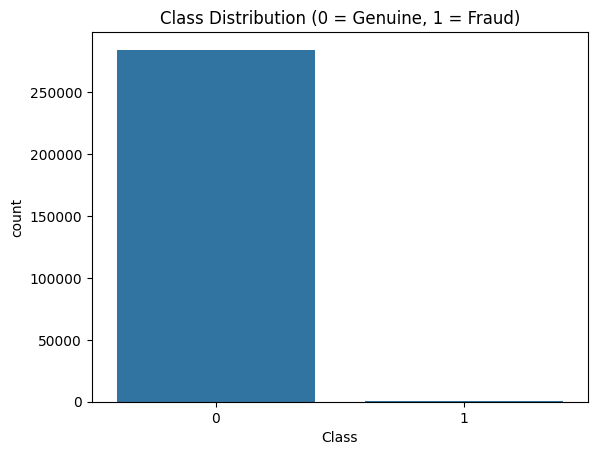

In [ ]:
print("Class Distribution:")
print(df['Class'].value_counts())

# Optional: Plot class distribution
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0 = Genuine, 1 = Fraud)')
plt.show()


In [ ]:
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])

df.drop(['Time'], axis=1, inplace=True)


In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']


In [ ]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("After SMOTE:")
print(pd.Series(y_resampled).value_counts())


After SMOTE:
Class
0    284315
1    284315
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.3, random_state=42)


In [ ]:
model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
model.fit(X_train, y_train)



RandomForestClassifier(max_depth=10, n_estimators=50, random_state=42)

In [ ]:
y_pred = model.predict(X_test)


Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     85149
           1       1.00      0.98      0.99     85440

    accuracy                           0.99    170589
   macro avg       0.99      0.99      0.99    170589
weighted avg       0.99      0.99      0.99    170589

Confusion Matrix:


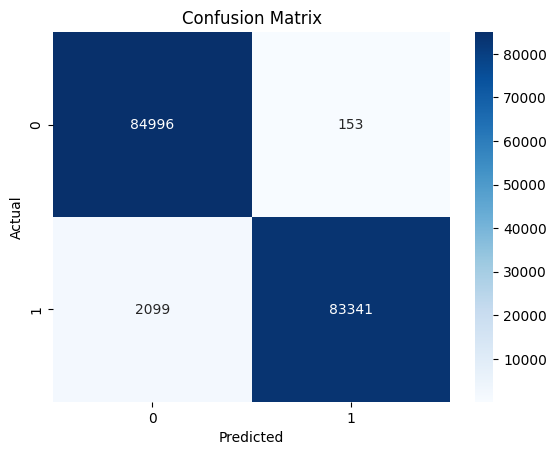

In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

print("Logistic Regression Report:")
print(classification_report(y_test, log_pred))


Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95     85149
           1       0.97      0.92      0.95     85440

    accuracy                           0.95    170589
   macro avg       0.95      0.95      0.95    170589
weighted avg       0.95      0.95      0.95    170589



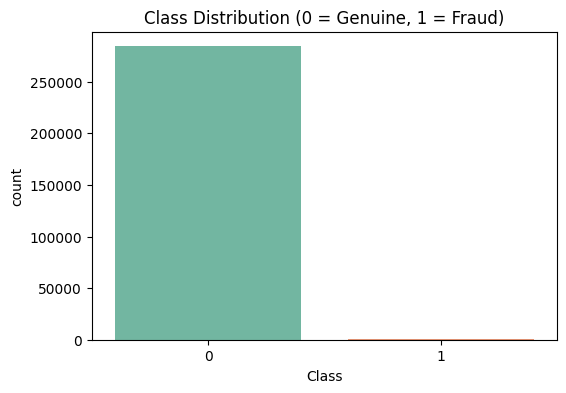

In [ ]:
# Plot class imbalance
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df, hue='Class', palette='Set2', legend=False)

plt.title('Class Distribution (0 = Genuine, 1 = Fraud)')
plt.show()



In [ ]:
print(df.columns)


Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class'],
      dtype='object')


In [ ]:
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])



/tmp/ipython-input-17-4200705370.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Amount', data=df, palette='coolwarm')


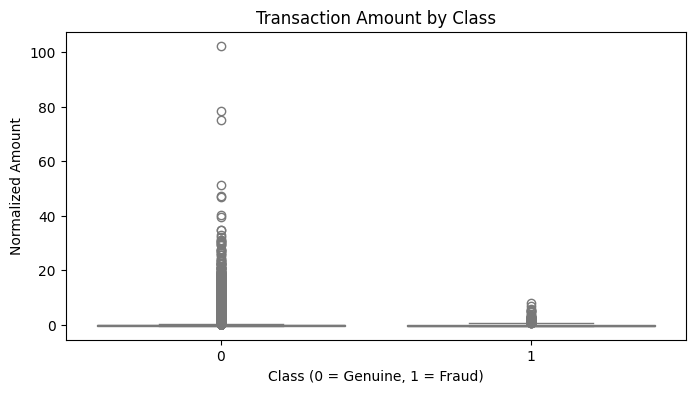

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x='Class', y='Amount', data=df, palette='coolwarm')
plt.title('Transaction Amount by Class')
plt.xlabel('Class (0 = Genuine, 1 = Fraud)')
plt.ylabel('Normalized Amount')
plt.show()


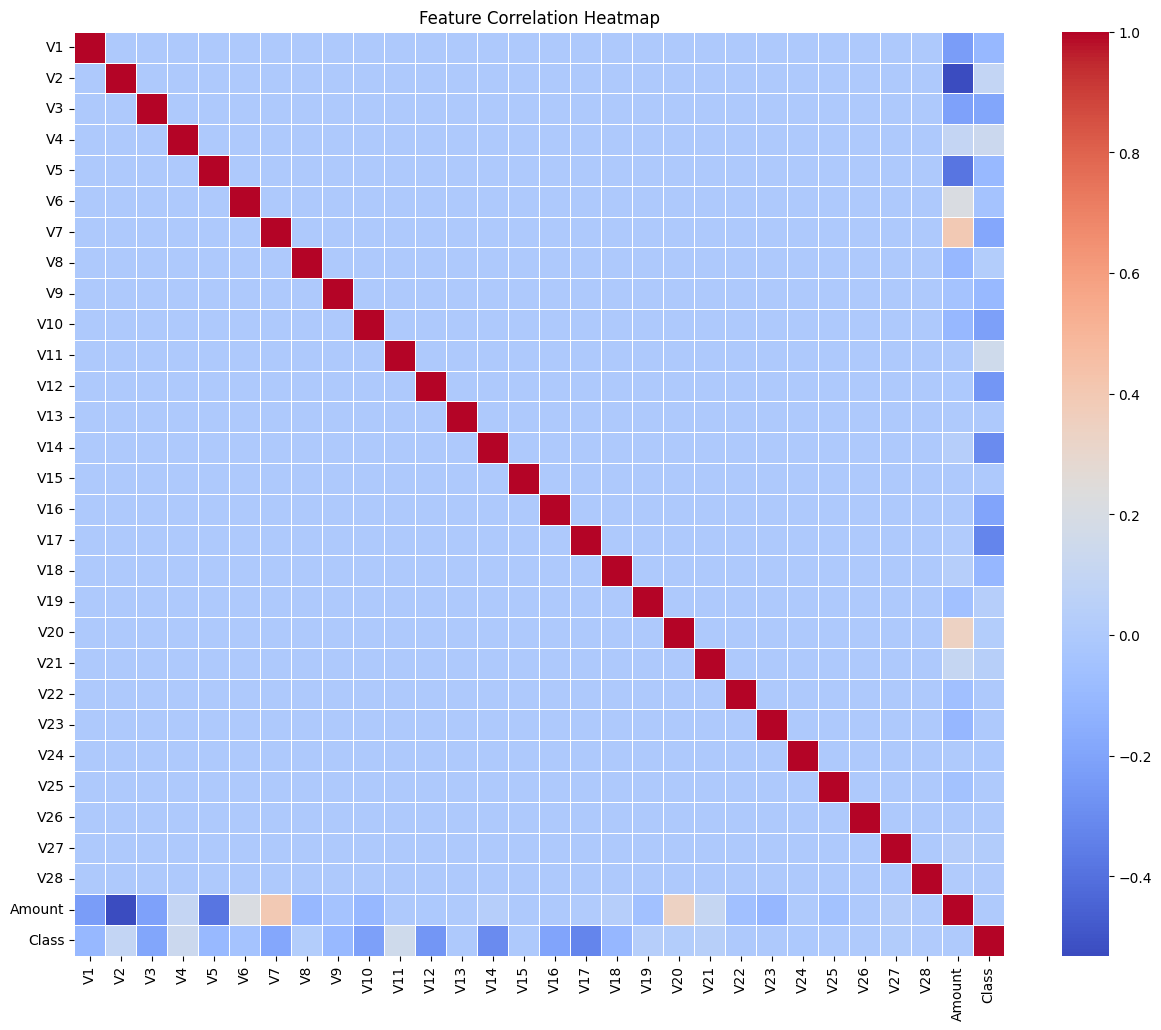

In [ ]:
plt.figure(figsize=(15,12))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()
